# Tanglegram — host vs parasite trees

**Chunk 1:** load the two trees and the parasite → host mapping, then peek at the data.

In [1]:
from Bio import Phylo
import json

# --- Paths to the gopher-louse dataset (same data main.ipynb uses) ---
host_tree_path = 'data/gopher_louse/gopher.nwk'      # hosts = pocket gophers
parasite_tree_path = 'data/gopher_louse/louse.nwk'   # parasites = chewing lice
mapping_path = 'data/gopher_louse/mapping.json'      # which louse lives on which gopher

# --- Load the two trees (Newick format) ---
host_tree = Phylo.read(host_tree_path, 'newick')
parasite_tree = Phylo.read(parasite_tree_path, 'newick')

# --- Load the parasite -> host association ---
with open(mapping_path, encoding='utf-8') as f:
    mapping = json.load(f)

# --- Peek at what we loaded ---
host_leaves = [leaf.name for leaf in host_tree.get_terminals()]
parasite_leaves = [leaf.name for leaf in parasite_tree.get_terminals()]

print(f'Hosts ({len(host_leaves)}):', host_leaves)
print(f'Parasites ({len(parasite_leaves)}):', parasite_leaves)
print('Mapping (parasite -> host):')
for parasite, host in mapping.items():
    print(f'   {parasite}  ->  {host}')

Hosts (8): ['T. talpoides', 'T. bottae', 'G. bursarius', 'O. hispidus', 'O. cavator', 'O. underwoodi', 'O. cherriei', 'O. heterodus']
Parasites (10): ['T. wardi', 'T. minor', 'G. thomomyus', 'G. actuosi', 'G. ewingi', 'G. chapini', 'G. panamensis', 'G. setzeri', 'G. cherriei', 'G. costaricensis']
Mapping (parasite -> host):
   G. chapini  ->  O. hispidus
   G. ewingi  ->  G. bursarius
   G. actuosi  ->  T. bottae
   T. minor  ->  T. bottae
   G. setzeri  ->  O. underwoodi
   T. wardi  ->  T. talpoides
   G. costaricensis  ->  O. heterodus
   G. cherriei  ->  O. cherriei
   G. thomomyus  ->  T. talpoides
   G. panamensis  ->  O. cavator


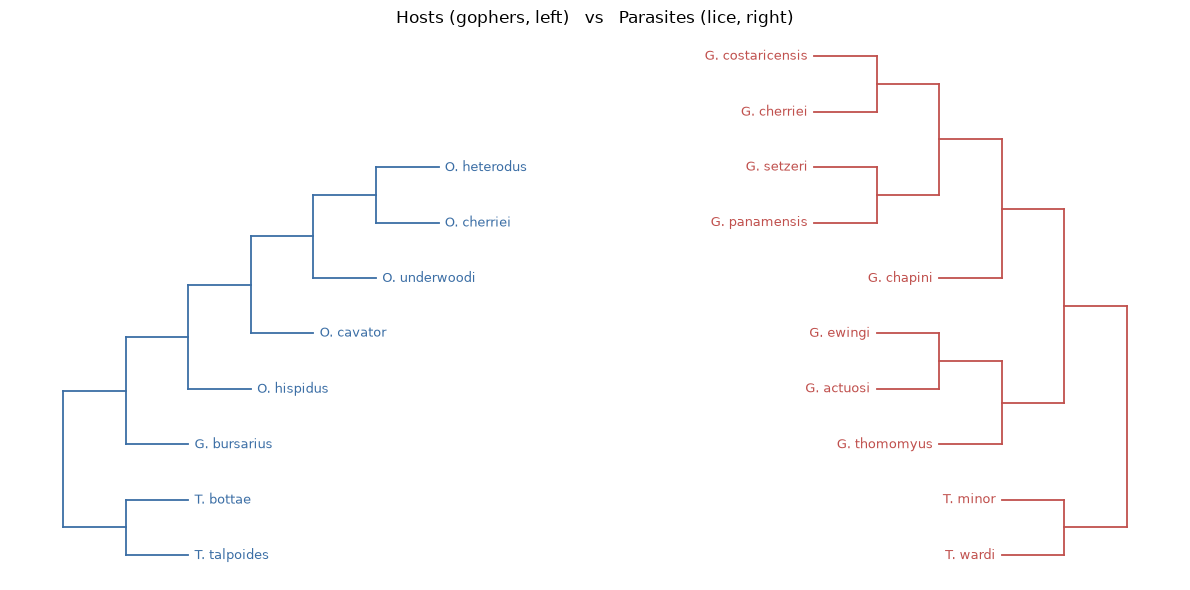

In [2]:
import matplotlib.pyplot as plt

# --- Helper 1: give every node an (x, y) position ---
def assign_positions(tree, x_root, x_dir):
    # x = how deep the node is from the root (branch lengths are all 0, so we count levels)
    depths = tree.depths(unit_branch_lengths=True)
    xpos = {clade: x_root + x_dir * depths[clade] for clade in depths}
    # y = leaves spread evenly; an internal node sits at the average height of its children
    leaves = tree.get_terminals()
    ypos = {leaf: float(i) for i, leaf in enumerate(leaves)}
    def set_internal_y(clade):
        for child in clade.clades:
            if child not in ypos:
                set_internal_y(child)
        if clade.clades:
            ypos[clade] = (ypos[clade.clades[0]] + ypos[clade.clades[-1]]) / 2
    set_internal_y(tree.root)
    return xpos, ypos

# --- Helper 2: draw the branches of a tree (rectangular style) ---
def draw_tree(ax, tree, xpos, ypos, color):
    for clade in tree.find_clades():
        children = clade.clades
        if children:
            ys = [ypos[c] for c in children]
            ax.plot([xpos[clade], xpos[clade]], [min(ys), max(ys)], color=color, lw=1.3)          # vertical
            for child in children:
                ax.plot([xpos[clade], xpos[child]], [ypos[child], ypos[child]], color=color, lw=1.3)  # horizontal

# --- Place the two trees facing each other ---
host_depth = max(host_tree.depths(unit_branch_lengths=True).values())
para_depth = max(parasite_tree.depths(unit_branch_lengths=True).values())
GAP = 6  # horizontal space between the two trees

host_x, host_y = assign_positions(host_tree, 0, +1)                                   # host: root left, tips point right
para_x, para_y = assign_positions(parasite_tree, host_depth + GAP + para_depth, -1)   # parasite: root right, tips point left (mirrored)

# --- Draw ---
fig, ax = plt.subplots(figsize=(12, 6))
draw_tree(ax, host_tree, host_x, host_y, '#3b6ea5')      # blue = hosts
draw_tree(ax, parasite_tree, para_x, para_y, '#c0504d')  # red = parasites

for leaf in host_tree.get_terminals():
    ax.text(host_x[leaf] + 0.1, host_y[leaf], leaf.name, va='center', ha='left', fontsize=9, color='#3b6ea5')
for leaf in parasite_tree.get_terminals():
    ax.text(para_x[leaf] - 0.1, para_y[leaf], leaf.name, va='center', ha='right', fontsize=9, color='#c0504d')

ax.set_title('Hosts (gophers, left)   vs   Parasites (lice, right)')
ax.axis('off')
plt.tight_layout()
plt.show()

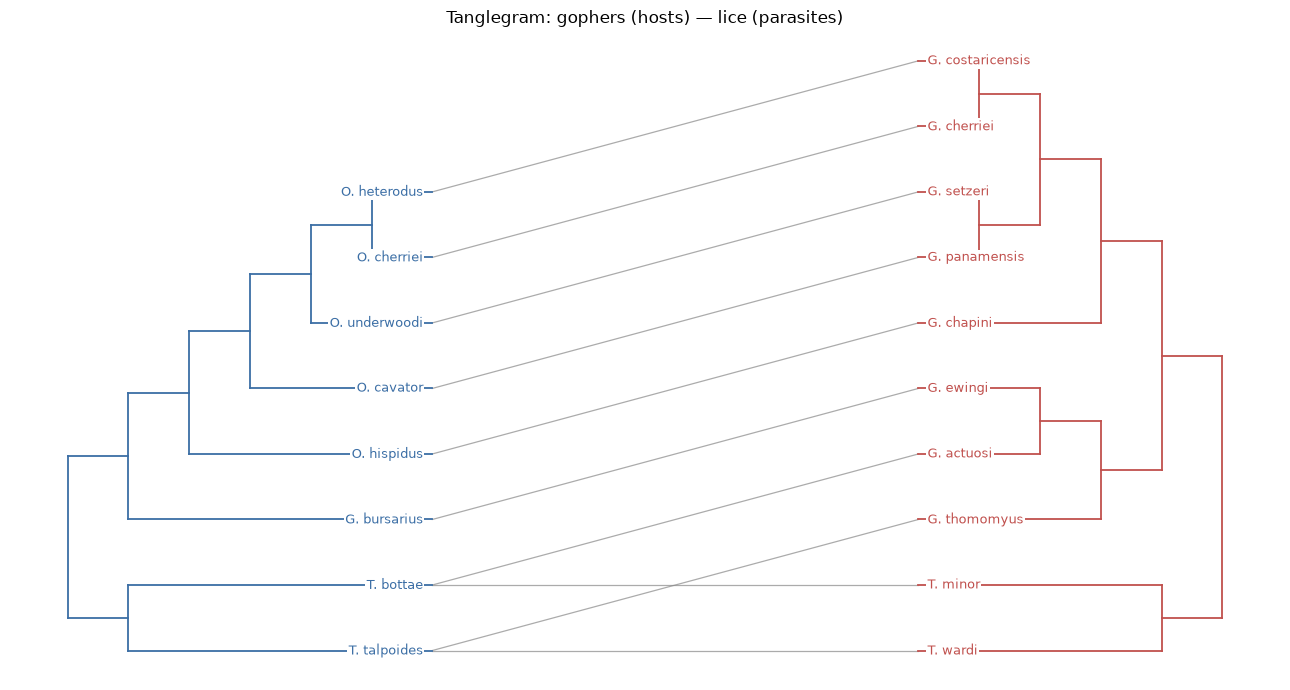

In [3]:
# Chunk 3: the full tanglegram — connect each parasite to its host
import matplotlib.pyplot as plt

# assign_positions, improved: align the tips to a straight line (cleaner connectors)
def assign_positions(tree, x_root, x_dir, align_tips=True):
    depths = tree.depths(unit_branch_lengths=True)
    max_depth = max(depths.values())
    xpos = {}
    for clade in depths:
        d = max_depth if (align_tips and clade.is_terminal()) else depths[clade]
        xpos[clade] = x_root + x_dir * d
    leaves = tree.get_terminals()
    ypos = {leaf: float(i) for i, leaf in enumerate(leaves)}
    def set_internal_y(clade):
        for child in clade.clades:
            if child not in ypos:
                set_internal_y(child)
        if clade.clades:
            ypos[clade] = (ypos[clade.clades[0]] + ypos[clade.clades[-1]]) / 2
    set_internal_y(tree.root)
    return xpos, ypos

def draw_tree(ax, tree, xpos, ypos, color):
    for clade in tree.find_clades():
        children = clade.clades
        if children:
            ys = [ypos[c] for c in children]
            ax.plot([xpos[clade], xpos[clade]], [min(ys), max(ys)], color=color, lw=1.3)
            for child in children:
                ax.plot([xpos[clade], xpos[child]], [ypos[child], ypos[child]], color=color, lw=1.3)

# --- positions for both trees ---
host_depth = max(host_tree.depths(unit_branch_lengths=True).values())
para_depth = max(parasite_tree.depths(unit_branch_lengths=True).values())
GAP = 8
host_x, host_y = assign_positions(host_tree, 0, +1)                                  # host on the left
para_x, para_y = assign_positions(parasite_tree, host_depth + GAP + para_depth, -1)  # parasite on the right (mirrored)

fig, ax = plt.subplots(figsize=(13, 7))

# 1) connector lines (drawn first, so they sit BEHIND the trees)
host_leaf_by_name = {leaf.name: leaf for leaf in host_tree.get_terminals()}
for p_leaf in parasite_tree.get_terminals():
    h_leaf = host_leaf_by_name[mapping[p_leaf.name]]
    ax.plot([host_x[h_leaf], para_x[p_leaf]], [host_y[h_leaf], para_y[p_leaf]],
            color='#888888', lw=0.9, alpha=0.7, zorder=0)

# 2) the two trees
draw_tree(ax, host_tree, host_x, host_y, '#3b6ea5')      # blue = hosts
draw_tree(ax, parasite_tree, para_x, para_y, '#c0504d')  # red = parasites

# 3) leaf names, with a white background so branch lines don't cross the text
label_bg = dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none')
for leaf in host_tree.get_terminals():
    ax.text(host_x[leaf] - 0.15, host_y[leaf], leaf.name, va='center', ha='right', fontsize=9, color='#3b6ea5', bbox=label_bg)
for leaf in parasite_tree.get_terminals():
    ax.text(para_x[leaf] + 0.15, para_y[leaf], leaf.name, va='center', ha='left', fontsize=9, color='#c0504d', bbox=label_bg)

ax.set_title('Tanglegram: gophers (hosts) — lice (parasites)')
ax.axis('off')
plt.tight_layout()
plt.show()

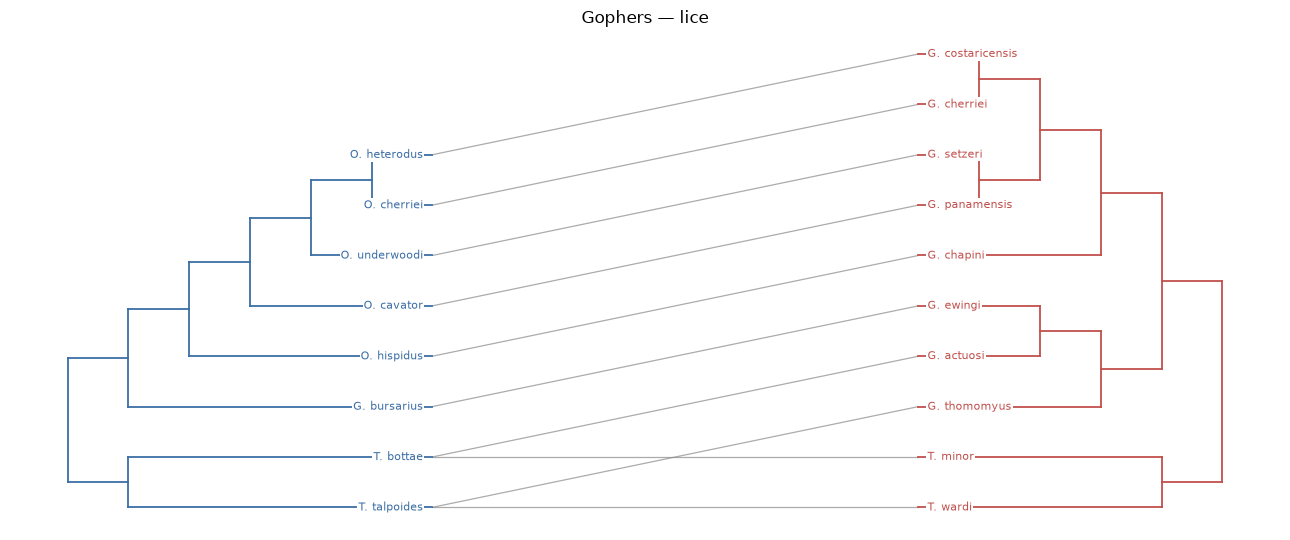

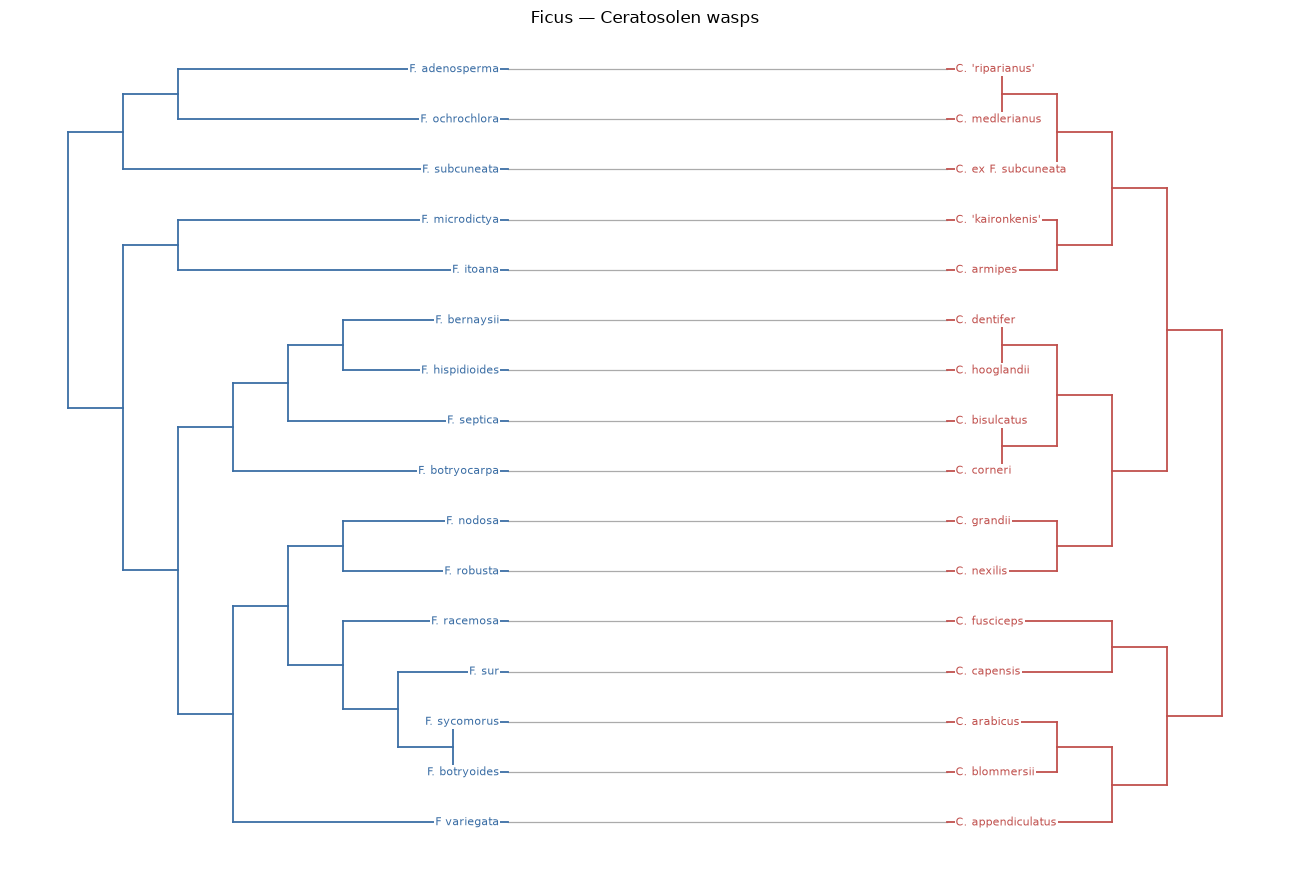

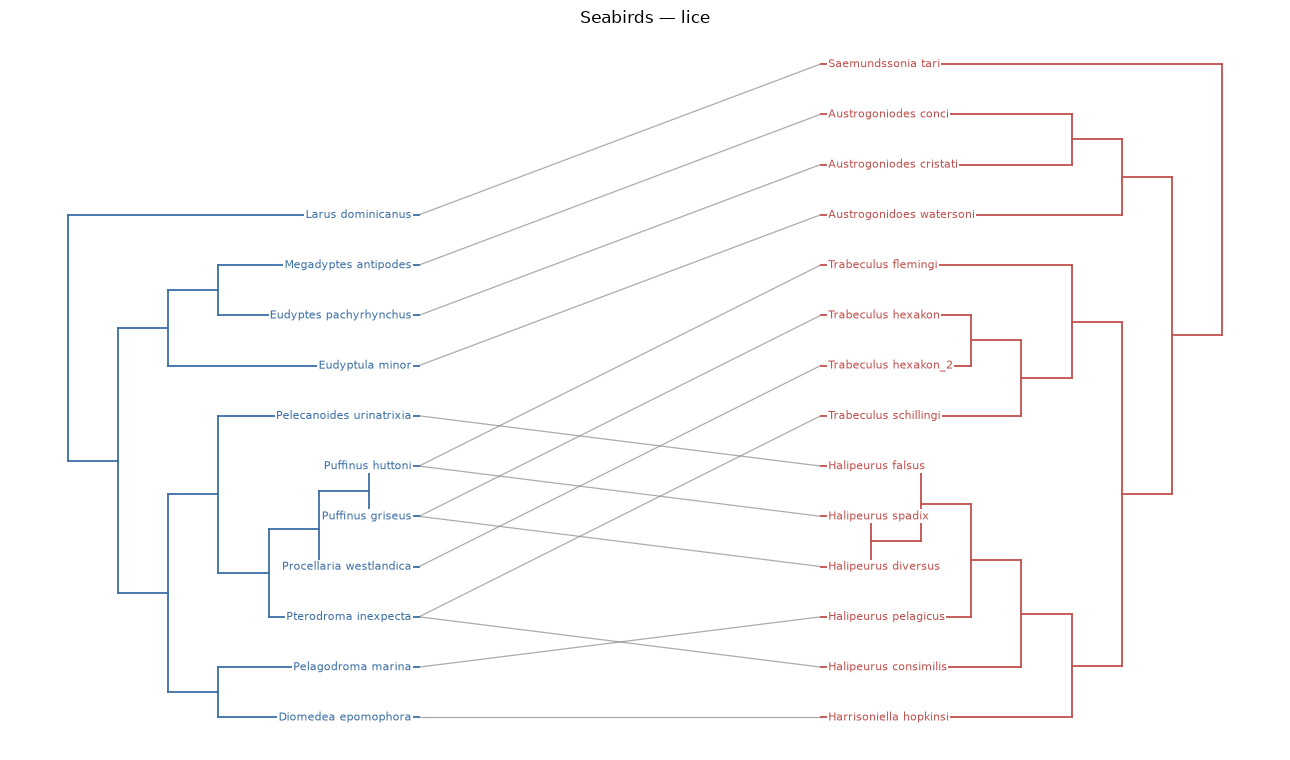

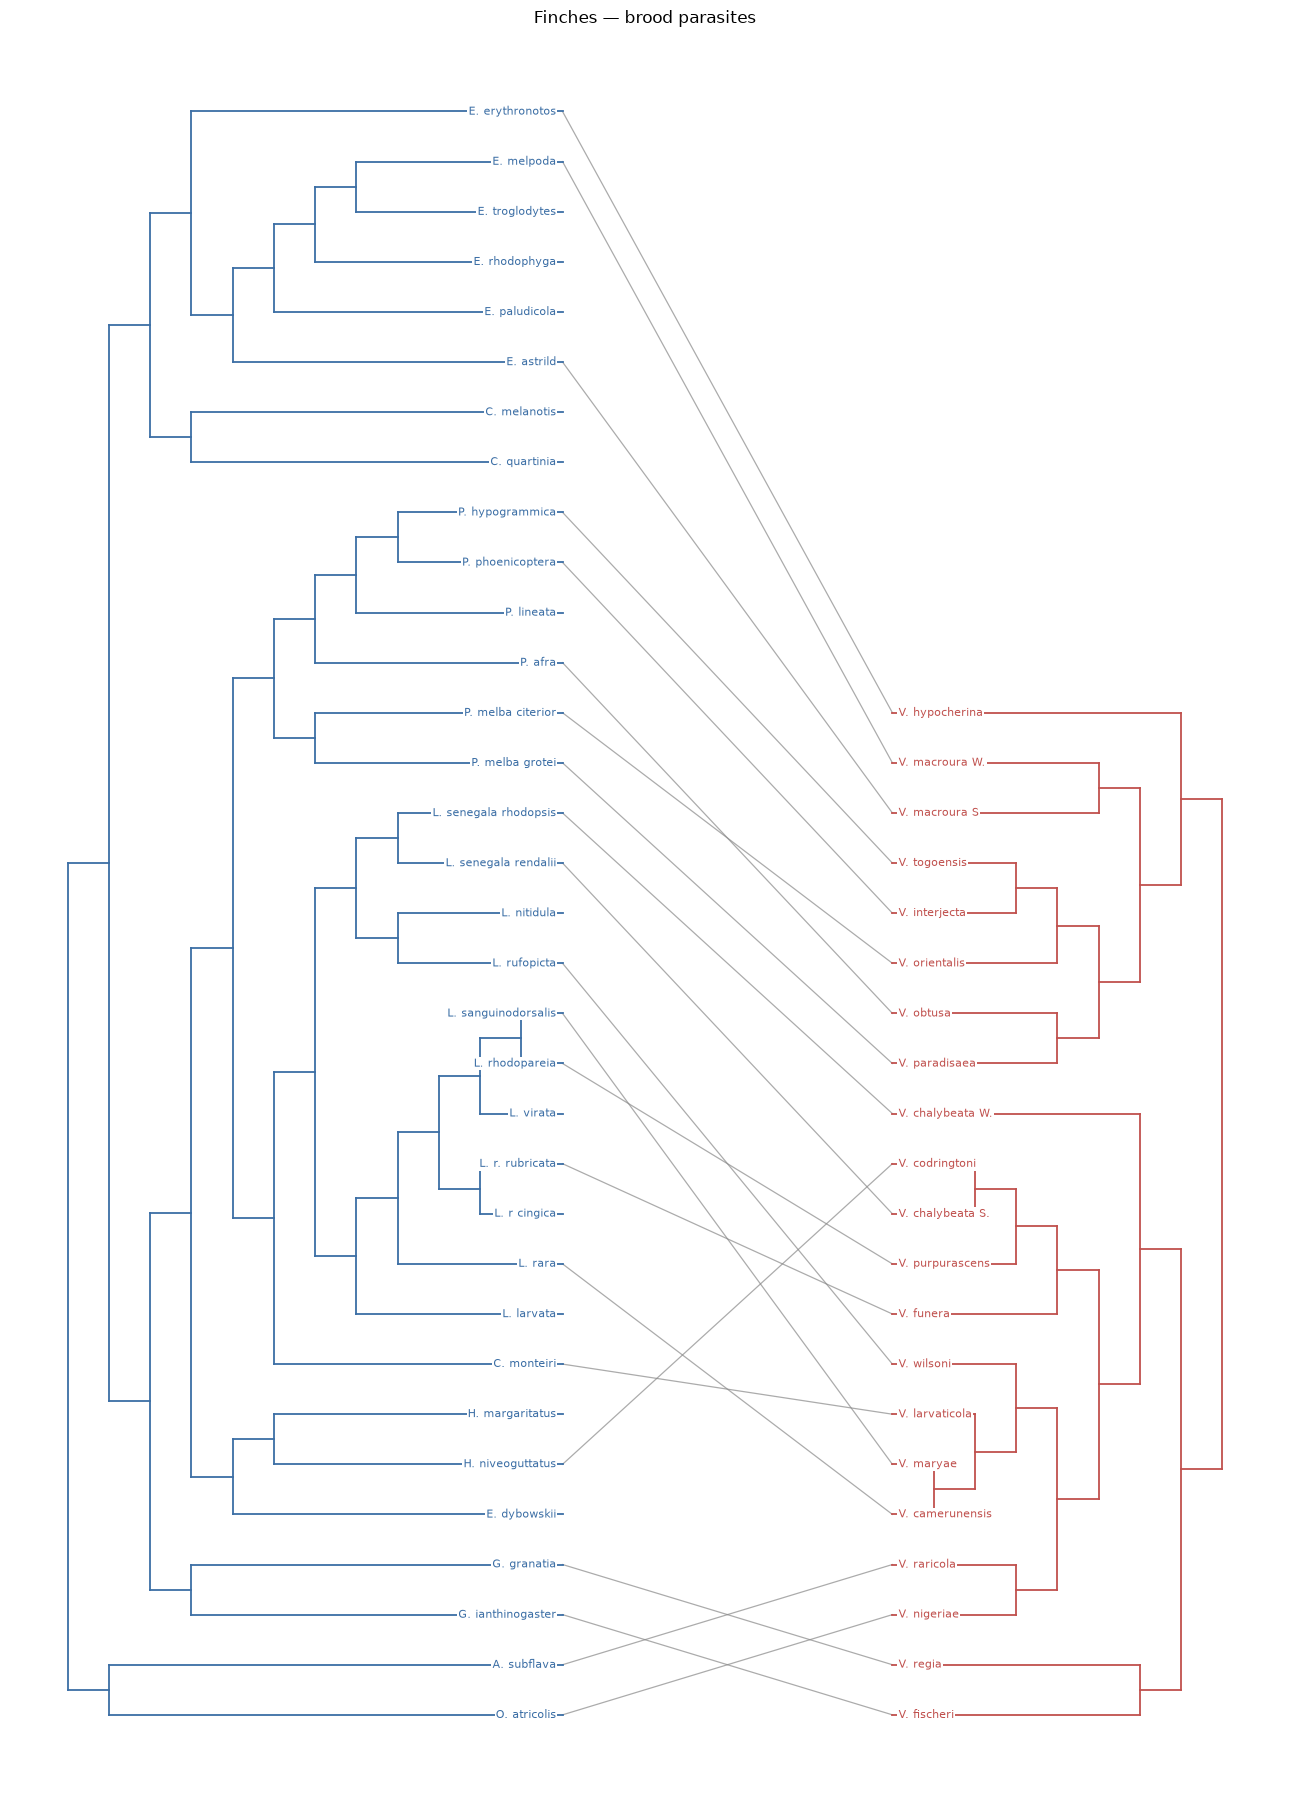

In [6]:
# Chunk 4: make it reusable — one function that draws ANY dataset
import os, json, glob

def load_dataset(folder):
    """Load host tree, parasite tree, and mapping from a dataset folder.
    Auto-detects which .nwk is the host vs the parasite, using the mapping
    (its keys are parasite names, its values are host names)."""
    with open(os.path.join(folder, 'mapping.json'), encoding='utf-8') as f:
        mapping = json.load(f)
    parasite_names = set(mapping.keys())
    host_tree = parasite_tree = None
    for path in glob.glob(os.path.join(folder, '*.nwk')):
        tree = Phylo.read(path, 'newick')
        leaves = {leaf.name for leaf in tree.get_terminals()}
        if len(leaves & parasite_names) > len(leaves) / 2:   # most leaves are parasite names
            parasite_tree = tree
        else:
            host_tree = tree
    return host_tree, parasite_tree, mapping


def draw_tanglegram(dataset, title=None):
    """Draw a full tanglegram for any dataset folder under data/."""
    host_tree, parasite_tree, mapping = load_dataset(os.path.join('data', dataset))

    host_depth = max(host_tree.depths(unit_branch_lengths=True).values())
    para_depth = max(parasite_tree.depths(unit_branch_lengths=True).values())
    GAP = 8
    host_x, host_y = assign_positions(host_tree, 0, +1)
    para_x, para_y = assign_positions(parasite_tree, host_depth + GAP + para_depth, -1)

    n = max(host_tree.count_terminals(), parasite_tree.count_terminals())
    fig, ax = plt.subplots(figsize=(13, max(4, n * 0.55)))   # taller figure for bigger trees

    # 1) connector lines
    host_by_name = {leaf.name: leaf for leaf in host_tree.get_terminals()}
    for p_leaf in parasite_tree.get_terminals():
        h_leaf = host_by_name.get(mapping.get(p_leaf.name))
        if h_leaf is not None:
            ax.plot([host_x[h_leaf], para_x[p_leaf]], [host_y[h_leaf], para_y[p_leaf]],
                    color='#888888', lw=0.9, alpha=0.7, zorder=0)

    # 2) the two trees
    draw_tree(ax, host_tree, host_x, host_y, '#3b6ea5')
    draw_tree(ax, parasite_tree, para_x, para_y, '#c0504d')

    # 3) labels with white background
    label_bg = dict(boxstyle='square,pad=0.1', facecolor='white', edgecolor='none')
    for leaf in host_tree.get_terminals():
        ax.text(host_x[leaf] - 0.15, host_y[leaf], leaf.name, va='center', ha='right', fontsize=8, color='#3b6ea5', bbox=label_bg)
    for leaf in parasite_tree.get_terminals():
        ax.text(para_x[leaf] + 0.15, para_y[leaf], leaf.name, va='center', ha='left', fontsize=8, color='#c0504d', bbox=label_bg)

    ax.set_title(title or f'Tanglegram: {dataset}')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Try it — just change the name inside the quotes:
draw_tanglegram('gopher_louse', 'Gophers — lice')
draw_tanglegram('ficus_ceratosolen', 'Ficus — Ceratosolen wasps')
draw_tanglegram('seabird_louse', 'Seabirds — lice')
draw_tanglegram('finches_african_brood_parasites', 'Finches — brood parasites')